# Spectroscopic Tools: Calibration, Resolution, and Line Spread Functions

tengri provides differentiable (JAX) functions for instrument-level effects
in pixel-level spectral fitting: flux calibration errors, finite resolution,
velocity broadening, and emission-line blending. All demos use synthetic
spectra -- **no external data files required**.

In [1]:
import warnings
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri.models.observation.calibration import (
    apply_calibration, calibration_polynomial, chebyshev_basis,
)
from tengri.models.observation.spectroscopy import (
    SSP_LIBRARY_RESOLUTIONS, apply_lsf, blend_emission_lines,
    nirspec_g140m_resolution, nirspec_prism_resolution, velocity_broaden,
)
jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Chebyshev Calibration Polynomial

A low-order Chebyshev polynomial absorbs wavelength-dependent calibration
errors (slit losses, telluric residuals) multiplicatively:
$C(\lambda) = 1 + \sum_{n=1}^{N} a_n T_n(x)$, where $x \in [-1,1]$.
Coefficients use a Gaussian(0, 0.1) prior toward flat calibration.

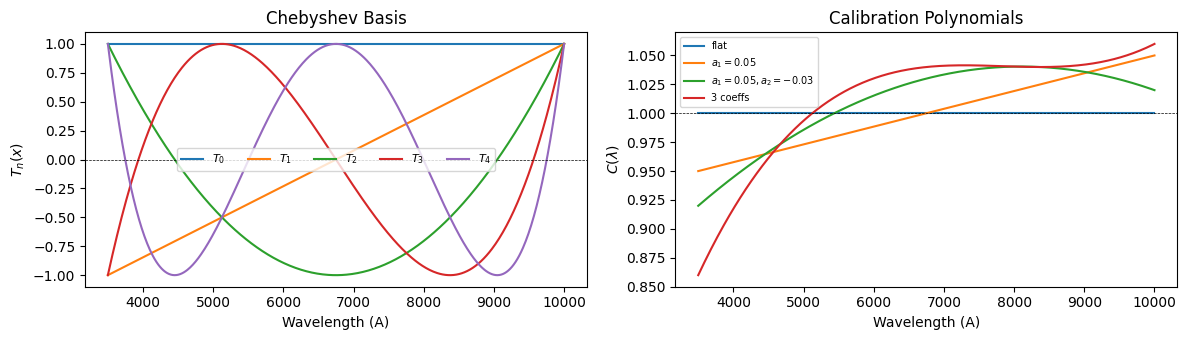

In [2]:
wave = jnp.linspace(3500.0, 10000.0, 500)
basis = chebyshev_basis(wave, order=4, wave_min=3500.0, wave_max=10000.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for n in range(5):
    axes[0].plot(wave, basis[n], label=f"$T_{n}$")
axes[0].set(xlabel="Wavelength (A)", ylabel="$T_n(x)$", title="Chebyshev Basis")
axes[0].legend(ncol=5, fontsize=8); axes[0].axhline(0, color="k", lw=0.5, ls="--")

for label, c in [("flat", jnp.zeros(0)), ("$a_1{=}0.05$", jnp.array([0.05])),
    ("$a_1{=}0.05, a_2{=}{-}0.03$", jnp.array([0.05, -0.03])),
    ("3 coeffs", jnp.array([0.08, -0.04, 0.02]))]:
    y = jnp.ones_like(wave) if c.size == 0 else calibration_polynomial(wave, c, 3500., 10000.)
    axes[1].plot(wave, y, label=label)
axes[1].set(xlabel="Wavelength (A)", ylabel="$C(\\lambda)$", title="Calibration Polynomials")
axes[1].axhline(1, color="k", lw=0.5, ls="--"); axes[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

W0325 23:00:57.046665 21010311 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


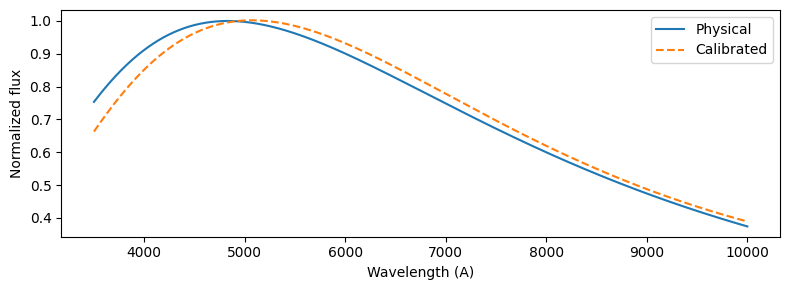

In [3]:
# Before/after on a mock blackbody
h, c_cgs, k_B = 6.626e-27, 3e10, 1.381e-16
wc = wave * 1e-8
bb = 2*h*c_cgs**2 / wc**5 / (jnp.exp(h*c_cgs / (wc*k_B*6000.)) - 1); bb = bb / bb.max()
calibrated = apply_calibration(bb, wave, jnp.array([0.06, -0.04, 0.02]), 3500., 10000.)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(wave, bb, label="Physical"); ax.plot(wave, calibrated, ls="--", label="Calibrated")
ax.set(xlabel="Wavelength (A)", ylabel="Normalized flux"); ax.legend()
fig.tight_layout(); plt.show()

## 2. Instrument Resolution Profiles

- **NIRSpec PRISM**: wavelength-dependent, $R \approx 30$--$330$ (0.6--5.3 um)
- **NIRSpec G140M**: constant $R \approx 1000$

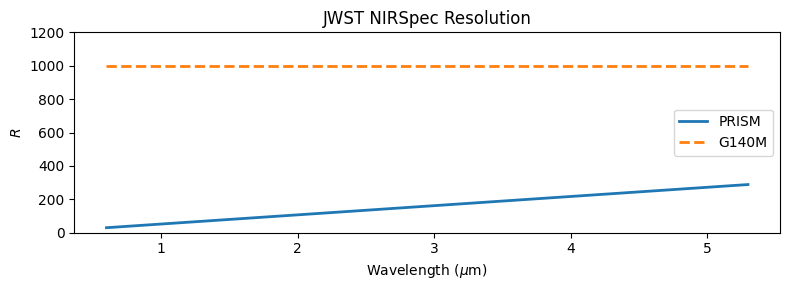

In [4]:
wave_um = jnp.linspace(0.6, 5.3, 500)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(wave_um, nirspec_prism_resolution(wave_um), lw=2, label="PRISM")
ax.plot(wave_um, nirspec_g140m_resolution(wave_um), lw=2, ls="--", label="G140M")
ax.set(xlabel="Wavelength ($\\mu$m)", ylabel="$R$", ylim=(0, 1200),
       title="JWST NIRSpec Resolution"); ax.legend()
fig.tight_layout(); plt.show()

## 3. Line Spread Function (LSF)

Constant-$R$ convolution is a single FFT in $\ln\lambda$. The effective
width subtracts SSP library resolution in quadrature:
$\sigma_{\rm eff} = \sqrt{\sigma_{\rm inst}^2 - \sigma_{\rm lib}^2}$.
For variable $R(\lambda)$, `apply_lsf` uses piecewise-constant bins.

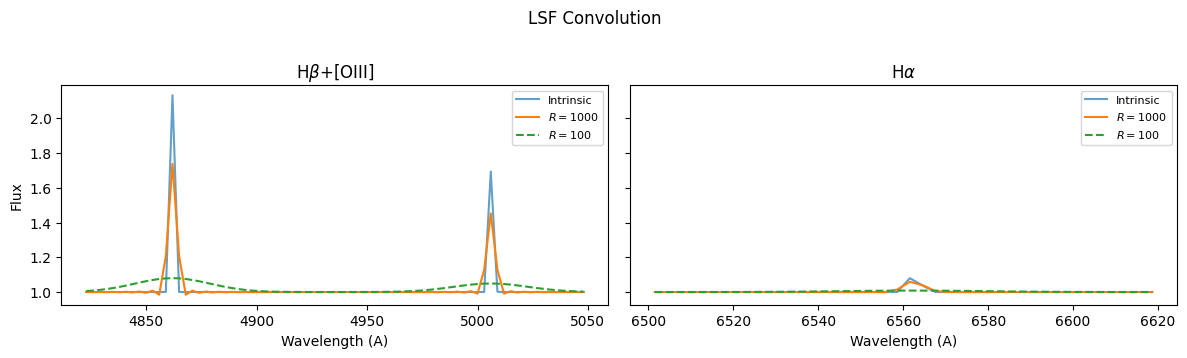

In [5]:
n_pix = 1000
wl = jnp.linspace(4000., 7000., n_pix)
raw = jnp.ones(n_pix)
for lc in [4861., 5007., 6563.]:
    raw = raw + 5.0 * jnp.exp(-0.5 * ((wl - lc) / 0.5)**2)
sm100 = apply_lsf(raw, wl, resolution=100.0)
sm1k = apply_lsf(raw, wl, resolution=1000.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, rng, t in zip(axes, [(4820,5050),(6500,6620)], ["H$\\beta$+[OIII]","H$\\alpha$"]):
    m = (wl >= rng[0]) & (wl <= rng[1])
    ax.plot(wl[m], raw[m], label="Intrinsic", alpha=.7)
    ax.plot(wl[m], sm1k[m], label="$R=1000$"); ax.plot(wl[m], sm100[m], ls="--", label="$R=100$")
    ax.set(xlabel="Wavelength (A)", title=t); ax.legend(fontsize=8)
axes[0].set_ylabel("Flux")
fig.suptitle("LSF Convolution", y=1.01); fig.tight_layout(); plt.show()

In [6]:
print("SSP library resolutions:", SSP_LIBRARY_RESOLUTIONS)

SSP library resolutions: {'miles': 70.0, 'c3k': 15.0, 'fsps_default': 70.0}


## 4. Velocity Broadening

`velocity_broaden` convolves with a Gaussian in $\ln\lambda$ at a given
stellar velocity dispersion $\sigma$ (km/s).

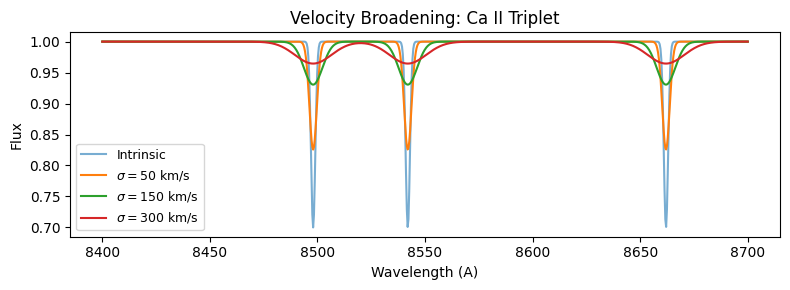

In [7]:
wv = jnp.linspace(8400., 8700., 800)
ab = jnp.ones(800)
for lc in [8498., 8542., 8662.]:  # Ca II triplet
    ab = ab - 0.3 * jnp.exp(-0.5 * ((wv - lc) / 1.)**2)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(wv, ab, label="Intrinsic", alpha=.6)
for sv in [50., 150., 300.]:
    ax.plot(wv, velocity_broaden(ab, wv, sv), label=f"$\\sigma={sv:.0f}$ km/s")
ax.set(xlabel="Wavelength (A)", ylabel="Flux", title="Velocity Broadening: Ca II Triplet")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

## 5. Emission Line Blending

`blend_emission_lines` places lines as Gaussians whose width is set by $R$.
At low resolution, nearby lines merge (e.g., [NII]+H$\alpha$).

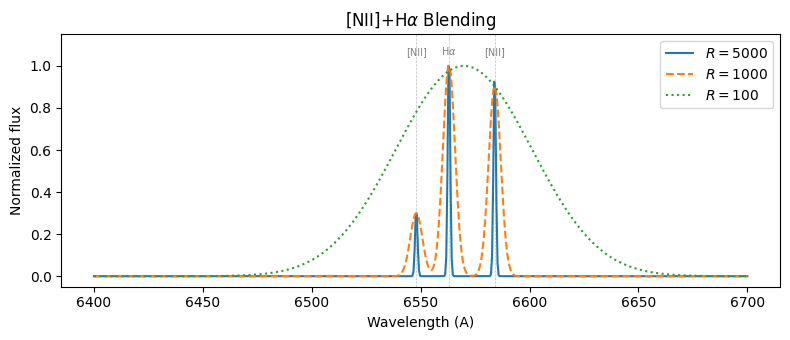

In [8]:
wb = jnp.linspace(6400., 6700., 600)
lw = jnp.array([6548., 6563., 6584.])  # [NII], Halpha, [NII]
ll = jnp.array([0.3, 1.0, 0.9])
fig, ax = plt.subplots(figsize=(8, 3.5))
for R, ls in [(5000,"-"), (1000,"--"), (100,":")]:
    bl = blend_emission_lines(lw, ll, float(R), wb)
    ax.plot(wb, bl / bl.max(), ls=ls, label=f"$R={R}$")
for w, n in zip(lw, ["[NII]","H$\\alpha$","[NII]"]):
    ax.axvline(w, color="gray", lw=.5, ls="--", alpha=.5)
    ax.text(w, 1.05, n, ha="center", fontsize=7, color="gray")
ax.set(xlabel="Wavelength (A)", ylabel="Normalized flux",
       title="[NII]+H$\\alpha$ Blending", ylim=(-.05, 1.15))
ax.legend(); fig.tight_layout(); plt.show()

## Summary

| Function | Purpose |
|----------|---------|
| `chebyshev_basis` | Evaluate $T_0$--$T_N$ basis |
| `calibration_polynomial` | $C(\lambda)=1+\sum a_n T_n$ |
| `apply_calibration` | Multiply spectrum by $C(\lambda)$ |
| `nirspec_prism_resolution` | Variable $R(\lambda)$ for PRISM |
| `nirspec_g140m_resolution` | Constant $R\approx1000$ |
| `apply_lsf` | Instrument LSF convolution |
| `velocity_broaden` | Stellar velocity dispersion |
| `blend_emission_lines` | Resolution-broadened line placement |

All functions are pure JAX, JIT-compatible, and differentiable -- suitable
for gradient-based inference with tengri's `Model` and `Fitter`.